# 09 – Train LSTM On Sequences (NTHU)

**Tujuan Notebook:**
Melatih dan membandingkan 8 kombinasi model sekuensial di atas fitur yang dihasilkan notebook `08`:

| ID | Backbone | Temporal Model |
|----|----------|----------------|
| 1  | CNN_BASIC | LSTM (2-layer, Stacked) |
| 2  | CNN_BASIC | BiLSTM (2-layer) |
| 3  | MOBILENET | LSTM |
| 4  | MOBILENET | BiLSTM |
| 5  | VGG19     | LSTM |
| 6  | VGG19     | BiLSTM |
| 7  | SWIN      | LSTM |
| 8  | SWIN      | BiLSTM |

Setiap model dilatih dengan Attention Mechanism (Additive/Bahdanau-style) yang bisa di-toggle.

**Input:** `sequences_nthuddd2/{MODEL}/{MODEL}_Seq_{Split}_NTHUD.pt`  
**Output:** `lstm_models_nthuddd2/{MODEL}_{LSTM_TYPE}/{MODEL}_{LSTM_TYPE}_BEST.pth`, `_LAST.pth`, `_history.json`

**Referensi Arsitektur:**
- CNN+BiLSTM outperforms BiLSTM-only (77.59% vs 70.69%) [CNN+BiLSTM Driver Drowsiness, SBC 2025]
- CNN+LSTM+Attention mencapai F1=96.8% pada drowsiness detection [ETASR 2025]
- Additive Attention lebih stabil untuk sequence pendek T≤30 frame

**Catatan penting:**
- BiLSTM **hanya valid untuk evaluasi offline** — tidak cocok deployment real-time
- LSTM standar adalah kandidat utama untuk sistem real-time
- Kedua arsitektur dibandingkan untuk keperluan analisis skripsi

# CELL 1 — Import & Konfigurasi Global

In [ ]:
import os, gc, json, time, random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score,
    recall_score, confusion_matrix, roc_auc_score
)
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# ─── SEED ──────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ─── DEVICE ────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ─── PATH ──────────────────────────────────────────────────
BASE_DIR      = r"C:\kuliah-sementara\SKRIPSI"
SEQ_DIR       = os.path.join(BASE_DIR, "sequences_nthuddd2")
SAVE_DIR      = os.path.join(BASE_DIR, "lstm_models_nthuddd2")
os.makedirs(SAVE_DIR, exist_ok=True)

# ─── DATA CONFIG ───────────────────────────────────────────
MODELS  = ["CNN_BASIC", "MOBILENET", "VGG19", "SWIN"]
SPLITS  = ["train", "val", "test"]
INPUT_DIM   = 512   # Dimensi fitur dari notebook 08 (semua backbone direduksi ke 512)
WINDOW_SIZE = 30    # T frame per sekuens (sesuai notebook 08)
LABEL_MAP   = {0: "drowsy", 1: "notdrowsy"}
NUM_CLASSES = 2

# ─── ARSITEKTUR LSTM ───────────────────────────────────────
LSTM_HIDDEN_DIM  = 256      # Hidden units per layer
LSTM_NUM_LAYERS  = 2        # Stacked LSTM (2-layer)
LSTM_DROPOUT     = 0.3      # Dropout antar layer LSTM
FC_DROPOUT       = 0.5      # Dropout sebelum FC classifier
USE_ATTENTION    = True     # Toggle Additive Attention

# ─── TRAINING HYPERPARAMETER ───────────────────────────────
BATCH_SIZE       = 64
MAX_EPOCHS       = 50
LEARNING_RATE    = 1e-3
WEIGHT_DECAY     = 1e-4     # L2 regularization
PATIENCE         = 10       # Early stopping patience (berdasarkan Val F1 Macro)

# ─── SCHEDULER ─────────────────────────────────────────────
LR_FACTOR        = 0.5      # Kurangi LR × 0.5 ketika plateau
LR_PATIENCE      = 5        # Epoch tunggu sebelum kurangi LR
LR_MIN           = 1e-6     # Batas bawah LR

# ─── DATALOADER ────────────────────────────────────────────
NUM_WORKERS      = 0        # Wajib 0 untuk Windows

# ─── PRINT KONFIGURASI ─────────────────────────────────────
print("=" * 65)
print("  KONFIGURASI 09 — TRAIN LSTM ON SEQUENCES")
print("=" * 65)
print(f"  Device          : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU             : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM total      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"  Sequences dir   : {SEQ_DIR}")
print(f"  Save dir        : {SAVE_DIR}")
print(f"  Input dim       : {INPUT_DIM}")
print(f"  Window size     : {WINDOW_SIZE}")
print(f"  LSTM hidden     : {LSTM_HIDDEN_DIM}")
print(f"  LSTM layers     : {LSTM_NUM_LAYERS}")
print(f"  Attention       : {USE_ATTENTION}")
print(f"  Batch size      : {BATCH_SIZE}")
print(f"  Max epochs      : {MAX_EPOCHS}")
print(f"  Learning rate   : {LEARNING_RATE}")
print(f"  Early stop pat. : {PATIENCE}")
print("=" * 65)

  KONFIGURASI 09 — TRAIN LSTM ON SEQUENCES
  Device          : cuda
  GPU             : NVIDIA GeForce RTX 3060
  VRAM total      : 12.9 GB
  Sequences dir   : C:\kuliah-sementara\SKRIPSI\sequences_nthuddd2
  Save dir        : C:\kuliah-sementara\SKRIPSI\lstm_models_nthuddd2
  Input dim       : 512
  Window size     : 30
  LSTM hidden     : 256
  LSTM layers     : 2
  Attention       : True
  Batch size      : 64
  Max epochs      : 50
  Learning rate   : 0.001
  Early stop pat. : 10


## 2. Validasi File Sekuens Input

Pastikan semua 12 file `.pt` hasil notebook 08 tersedia sebelum training dimulai.

In [26]:
print("[VALIDASI] Mengecek file sekuens input...\n")

all_ok = True
for model in MODELS:
    for split in SPLITS:
        fname = f"{model}_Seq_{split.capitalize()}_NTHUD.pt"
        fpath = os.path.join(SEQ_DIR, model, fname)
        exists = os.path.exists(fpath)

        if exists:
            data = torch.load(fpath, map_location="cpu", weights_only=False)
            n_seq   = data["features"].shape[0]
            n_drow  = int((data["labels"] == 0).sum())
            n_notd  = int((data["labels"] == 1).sum())
            balance = n_drow / n_seq * 100
            print(f"  [OK] {fname}")
            print(f"       Shape={list(data['features'].shape)} | "
                  f"drowsy={n_drow:,} ({balance:.1f}%) | notdrowsy={n_notd:,}")
        else:
            print(f"  [MISSING] {fname}")
            all_ok = False

print()
if not all_ok:
    raise FileNotFoundError(
        "Beberapa file .pt tidak ditemukan!\n"
        "Pastikan notebook 08_Build_Sequences_30Frames_NTHU sudah dijalankan."
    )
print("✓ Semua file sekuens tersedia. Siap melatih LSTM.")

[VALIDASI] Mengecek file sekuens input...

  [OK] CNN_BASIC_Seq_Train_NTHUD.pt
       Shape=[8053, 30, 512] | drowsy=4,502 (55.9%) | notdrowsy=3,551
  [OK] CNN_BASIC_Seq_Val_NTHUD.pt
       Shape=[3634, 30, 512] | drowsy=2,100 (57.8%) | notdrowsy=1,534
  [OK] CNN_BASIC_Seq_Test_NTHUD.pt
       Shape=[1302, 30, 512] | drowsy=548 (42.1%) | notdrowsy=754
  [OK] MOBILENET_Seq_Train_NTHUD.pt
       Shape=[8053, 30, 512] | drowsy=4,502 (55.9%) | notdrowsy=3,551
  [OK] MOBILENET_Seq_Val_NTHUD.pt
       Shape=[3634, 30, 512] | drowsy=2,100 (57.8%) | notdrowsy=1,534
  [OK] MOBILENET_Seq_Test_NTHUD.pt
       Shape=[1302, 30, 512] | drowsy=548 (42.1%) | notdrowsy=754
  [OK] VGG19_Seq_Train_NTHUD.pt
       Shape=[8053, 30, 512] | drowsy=4,502 (55.9%) | notdrowsy=3,551
  [OK] VGG19_Seq_Val_NTHUD.pt
       Shape=[3634, 30, 512] | drowsy=2,100 (57.8%) | notdrowsy=1,534
  [OK] VGG19_Seq_Test_NTHUD.pt
       Shape=[1302, 30, 512] | drowsy=548 (42.1%) | notdrowsy=754
  [OK] SWIN_Seq_Train_NTHUD.pt
     

## 3. Dataset Class & DataLoader

`SequenceDataset` membungkus file `.pt` menjadi PyTorch Dataset standar.
Normalisasi per-feature (Z-Score) diterapkan di sini menggunakan statistik dari **training set saja**
untuk mencegah data leakage ke val/test.
Hal ini krusial karena VGG19 memiliki std fitur ~1.24 vs CNN_BASIC ~0.09 — tanpa normalisasi,
LSTM untuk VGG19 akan belajar dari skala berbeda dan hasilnya tidak fair dibandingkan.

In [27]:
class SequenceDataset(Dataset):
    """
    Dataset wrapper untuk file sekuens .pt.
    Mendukung optional Z-Score normalisasi menggunakan
    mean/std dari training set.
    """
    def __init__(self, features: torch.Tensor, labels: torch.Tensor,
                 mean: torch.Tensor = None, std: torch.Tensor = None):
        self.features = features.float()
        self.labels   = labels.long()

        # Terapkan normalisasi jika tersedia
        if mean is not None and std is not None:
            # Clamp std agar tidak ada pembagian dengan 0
            std_safe = std.clamp(min=1e-8)
            self.features = (self.features - mean) / std_safe

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]


def load_split_data(model_name: str, split: str):
    """Load file .pt untuk satu backbone + satu split."""
    fname = f"{model_name}_Seq_{split.capitalize()}_NTHUD.pt"
    fpath = os.path.join(SEQ_DIR, model_name, fname)
    data  = torch.load(fpath, map_location="cpu", weights_only=False)
    return data["features"].float(), data["labels"].long()


def compute_train_stats(features: torch.Tensor):
    """
    Hitung mean & std dari training set untuk Z-Score normalisasi.
    Shape features: [N_seq, T, D] → statistik dihitung per dimensi D.
    """
    # Reshape ke [N*T, D] lalu hitung statistik per fitur
    N, T, D = features.shape
    flat    = features.reshape(-1, D)   # [N*T, D]
    mean    = flat.mean(dim=0)          # [D]
    std     = flat.std(dim=0)           # [D]
    return mean, std


def build_dataloaders(model_name: str, batch_size: int = 64):
    """
    Build train/val/test DataLoader untuk satu backbone.
    Normalisasi dihitung dari train set lalu diterapkan ke semua split.

    Returns:
        loaders    : dict {"train": ..., "val": ..., "test": ...}
        class_weight : Tensor untuk weighted CrossEntropyLoss
        norm_stats : dict {"mean": ..., "std": ...}
    """
    # Load semua split
    train_feat, train_lab = load_split_data(model_name, "train")
    val_feat,   val_lab   = load_split_data(model_name, "val")
    test_feat,  test_lab  = load_split_data(model_name, "test")

    # Hitung normalisasi dari train set saja
    mean, std = compute_train_stats(train_feat)

    # Buat dataset (val & test menggunakan mean/std dari train)
    train_ds = SequenceDataset(train_feat, train_lab, mean, std)
    val_ds   = SequenceDataset(val_feat,   val_lab,   mean, std)
    test_ds  = SequenceDataset(test_feat,  test_lab,  mean, std)

    # ── Class Weight untuk imbalance handling ─────────────────
    # Rumus: w_c = N_total / (num_classes × N_c)
    label_counts = Counter(train_lab.numpy())
    n_total      = len(train_lab)
    weights      = torch.tensor([
        n_total / (NUM_CLASSES * label_counts[c])
        for c in range(NUM_CLASSES)
    ], dtype=torch.float32)

    print(f"  [Normalisasi] feat_mean={mean.mean():.4f}, feat_std={std.mean():.4f}")
    print(f"  [ClassWeight] drowsy={weights[0]:.4f}, notdrowsy={weights[1]:.4f}")

    loaders = {
        "train": DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                            num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=="cuda")),
        "val"  : DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=="cuda")),
        "test" : DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=="cuda")),
    }

    norm_stats = {"mean": mean, "std": std}
    return loaders, weights, norm_stats


print("✓ Fungsi Dataset dan DataLoader terdefinisi.")

✓ Fungsi Dataset dan DataLoader terdefinisi.


## 4. Arsitektur Model

### Additive Attention (Bahdanau-style)
Mekanisme Attention bekerja seperti "penilai kepentingan" — dari 30 output LSTM (satu per frame),
model belajar frame mana yang paling informatif untuk keputusan akhir.
Analogi: dari rekaman 1 detik, model otomatis fokus ke momen ketika mata mulai menutup,
bukan rata-rata semua 30 frame.

### LSTM vs BiLSTM
- **LSTM**: membaca sequence dari frame 1 → 30. Cocok real-time.
- **BiLSTM**: membaca frame 1→30 DAN 30→1, lalu menggabungkan hasilnya.
  Lebih akurat untuk analisis offline karena melihat "konteks penuh."

In [ ]:
class AdditiveAttention(nn.Module):
    """
    Additive (Bahdanau-style) Attention untuk output LSTM.

    Input  : lstm_out → [B, T, H]  (H = hidden_dim atau 2*hidden_dim untuk BiLSTM) B = Batch Size, 
    T = Time Steps (Sequence Length), H = Hidden Dimension (Feature Size)
    Output : context → [B, H]      (weighted sum dari semua timestep)

    Cara kerja:
      1. Setiap timestep t mendapat skor energi e_t = v^T tanh(W * h_t)
      2. Skor di-softmax → attention weights α_t
      3. Context vector = Σ(α_t * h_t)
    """
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, hidden_dim)
        self.v    = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, lstm_out: torch.Tensor):
        # lstm_out: [B, T, H]
        energy   = torch.tanh(self.attn(lstm_out))     # [B, T, H]
        scores   = self.v(energy).squeeze(-1)           # [B, T]
        weights  = torch.softmax(scores, dim=-1)        # [B, T]
        context  = torch.bmm(
            weights.unsqueeze(1), lstm_out
        ).squeeze(1)                                    # [B, H]
        return context, weights


class DrowsinessLSTM(nn.Module):
    """
    Arsitektur utama: Stacked LSTM/BiLSTM + optional Attention + FC Classifier.

    Args:
        input_dim    : dimensi fitur per frame (512)
        hidden_dim   : unit hidden LSTM (256)
        num_layers   : jumlah layer LSTM (2)
        num_classes  : jumlah kelas (2)
        bidirectional: True = BiLSTM, False = LSTM standar
        use_attention: True = tambahkan Additive Attention
        lstm_dropout : dropout antar layer LSTM (hanya berlaku jika num_layers > 1)
        fc_dropout   : dropout sebelum FC classifier
    """
    def __init__(
        self,
        input_dim    : int   = 512,
        hidden_dim   : int   = 256,
        num_layers   : int   = 2,
        num_classes  : int   = 2,
        bidirectional: bool  = False,
        use_attention: bool  = True,
        lstm_dropout : float = 0.3,
        fc_dropout   : float = 0.5,
    ):
        super().__init__()
        self.bidirectional = bidirectional
        self.use_attention = use_attention
        self.hidden_dim    = hidden_dim
        self.num_layers    = num_layers
        num_directions     = 2 if bidirectional else 1
        lstm_out_dim       = hidden_dim * num_directions  # 256 atau 512

        # ── Layer Normalisasi Input ──────────────────────────
        # Menstabilkan input ke LSTM, membantu konvergensi
        self.input_norm = nn.LayerNorm(input_dim)

        # ── LSTM / BiLSTM ────────────────────────────────────
        self.lstm = nn.LSTM(
            input_size    = input_dim,
            hidden_size   = hidden_dim,
            num_layers    = num_layers,
            batch_first   = True,
            bidirectional = bidirectional,
            dropout       = lstm_dropout if num_layers > 1 else 0.0,
        )

        # ── Attention ────────────────────────────────────────
        if use_attention:
            self.attention = AdditiveAttention(lstm_out_dim)
            classifier_in  = lstm_out_dim
        else:
            # Tanpa attention: ambil hidden state terakhir saja
            self.attention  = None
            classifier_in   = lstm_out_dim

        # ── FC Classifier ────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Dropout(fc_dropout),
            nn.Linear(classifier_in, 128),
            nn.ReLU(),
            nn.Dropout(fc_dropout * 0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x: torch.Tensor):
        # x: [B, T, input_dim]
        x = self.input_norm(x)                          # [B, T, D]
        lstm_out, (h_n, _) = self.lstm(x)               # [B, T, H*num_dir]

        if self.use_attention:
            context, attn_weights = self.attention(lstm_out)  # [B, H*num_dir]
        else:
            # Ambil output timestep terakhir
            context      = lstm_out[:, -1, :]
            attn_weights = None

        logits = self.classifier(context)                # [B, num_classes]
        return logits, attn_weights


def build_model(bidirectional: bool = False, use_attention: bool = True) -> DrowsinessLSTM:
    """Factory function untuk membangun model dengan konfigurasi global."""
    return DrowsinessLSTM(
        input_dim     = INPUT_DIM,
        hidden_dim    = LSTM_HIDDEN_DIM,
        num_layers    = LSTM_NUM_LAYERS,
        num_classes   = NUM_CLASSES,
        bidirectional = bidirectional,
        use_attention = use_attention,
        lstm_dropout  = LSTM_DROPOUT,
        fc_dropout    = FC_DROPOUT,
    ).to(DEVICE)


# ── Tes arsitektur dengan dummy input ──────────────────────
print("[TEST] Arsitektur LSTM:")
_m = build_model(bidirectional=False)
_x = torch.randn(4, WINDOW_SIZE, INPUT_DIM).to(DEVICE) #test dengan bach 4
_out, _attn = _m(_x)
print(f"  Input  : {list(_x.shape)}")
print(f"  Output : {list(_out.shape)}")
print(f"  Attn   : {list(_attn.shape) if _attn is not None else 'None'}")
total_params = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f"  Params : {total_params:,}")
del _m, _x, _out, _attn

print("\n[TEST] Arsitektur BiLSTM:")
_m = build_model(bidirectional=True)
_x = torch.randn(4, WINDOW_SIZE, INPUT_DIM).to(DEVICE)
_out, _attn = _m(_x)
print(f"  Input  : {list(_x.shape)}")
print(f"  Output : {list(_out.shape)}")
total_params = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f"  Params : {total_params:,}")
del _m, _x, _out, _attn
torch.cuda.empty_cache()

print("\n✓ Arsitektur LSTM dan BiLSTM valid.")

[TEST] Arsitektur LSTM:
  Input  : [4, 30, 512]
  Output : [4, 2]
  Attn   : [4, 30]
  Params : 1,415,042

[TEST] Arsitektur BiLSTM:
  Input  : [4, 30, 512]
  Output : [4, 2]
  Params : 3,484,034

✓ Arsitektur LSTM dan BiLSTM valid.


## 5. Fungsi Training Core

Satu epoch training + satu epoch evaluasi (val/test).
Fungsi ini dipakai ulang untuk semua kombinasi model.

In [ ]:
def train_epoch(model, loader, criterion, optimizer):
    """Jalankan satu epoch training. Returns loss, accuracy, f1_macro."""
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for feats, labels in loader:
        feats  = feats.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad() #hapus dulu gradien sebelumnya
        logits, _ = model(feats)
        loss      = criterion(logits, labels)
        loss.backward()

        # Gradient clipping — cegah exploding gradients pada LSTM
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item() * len(labels)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc      = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, acc, f1


@torch.no_grad()
def evaluate(model, loader, criterion):
    """Evaluasi model (val atau test). Returns loss, accuracy, f1_macro, preds, labels."""
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for feats, labels in loader:
        feats  = feats.to(DEVICE)
        labels = labels.to(DEVICE)

        logits, _ = model(feats)
        loss      = criterion(logits, labels)

        total_loss += loss.item() * len(labels)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc      = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, acc, f1, np.array(all_preds), np.array(all_labels)


print("✓ Fungsi train_epoch dan evaluate terdefinisi.")

✓ Fungsi train_epoch dan evaluate terdefinisi.


## 6. Training Pipeline Utama

Fungsi `run_training()` adalah orkestrator lengkap yang menggabungkan:
- Build model + optimizer + scheduler
- Resume dari checkpoint (State Saving & Resume Training)
- Loop training dengan Early Stopping berbasis Val F1 Macro
- Simpan model terbaik (`_BEST.pth`) dan model terakhir (`_LAST.pth`)
- Catat semua history ke `_history.json`

In [ ]:
def run_training(
    backbone_name : str,
    bidirectional : bool = False,
    use_attention : bool = True,
    force_retrain : bool = False,
) -> dict:
    lstm_type  = "BILSTM" if bidirectional else "LSTM"
    model_id   = f"{backbone_name}_{lstm_type}"
    model_dir  = os.path.join(SAVE_DIR, model_id)
    os.makedirs(model_dir, exist_ok=True)

    path_best  = os.path.join(model_dir, f"{model_id}_BEST.pth")
    path_last  = os.path.join(model_dir, f"{model_id}_LAST.pth")
    path_hist  = os.path.join(model_dir, f"{model_id}_history.json")

    print("\n" + "=" * 65)
    print(f"  MODEL: {model_id}")
    print(f"  Attention: {use_attention} | Bidirectional: {bidirectional}")
    print("=" * 65)

    # ── 1. Load Data ─────────────────────────────────────────
    print("[1/7] Loading data & membangun DataLoader...")
    loaders, class_weight, norm_stats = build_dataloaders(backbone_name, BATCH_SIZE)
    class_weight = class_weight.to(DEVICE)

    # ── 2. Bangun Model ──────────────────────────────────────
    print("[2/7] Membangun model...")
    model     = build_model(bidirectional=bidirectional, use_attention=use_attention)
    
    # --- FAIR TUNING: Hyperparameter adaptif khusus untuk SWIN (Terinspirasi dr File 03_Model_MRL) ---
    if backbone_name == "SWIN":
        # Swin sangat sensitif: butuh AdamW, regulasi label smoothing & LR sedikit direm
        current_lr = 5e-4
        current_wd = 1e-2
        criterion  = nn.CrossEntropyLoss(weight=class_weight, label_smoothing=0.1)
        optimizer  = torch.optim.AdamW(model.parameters(), lr=current_lr, weight_decay=current_wd)
        print(f"  [Fair Tune] Menggunakan tuning khusus SWIN: AdamW (lr={current_lr}, wd={current_wd}) & Label Smoothing 0.1")
    else:
        current_lr = LEARNING_RATE # Bawaan: 1e-3
        current_wd = WEIGHT_DECAY  # Bawaan: 1e-4
        criterion  = nn.CrossEntropyLoss(weight=class_weight)
        optimizer  = torch.optim.Adam(model.parameters(), lr=current_lr, weight_decay=current_wd)

    # FIX: Hapus verbose= (deprecated di PyTorch ≥2.2)
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode      = "max",
        factor    = LR_FACTOR,
        patience  = LR_PATIENCE,
        min_lr    = LR_MIN,
        threshold = 1e-4,
    )

    # ── 3. Resume dari Checkpoint ────────────────────────────
    start_epoch      = 0
    best_val_f1      = -1.0
    patience_counter = 0
    history          = {
        "train_loss": [], "train_acc": [], "train_f1": [],
        "val_loss":   [], "val_acc":   [], "val_f1":   [],
        "lr":         [],
    }

    if os.path.exists(path_last) and not force_retrain:
        print(f"[3/7] ✓ Checkpoint ditemukan → Resume dari {path_last}")
        ckpt             = torch.load(path_last, map_location=DEVICE, weights_only=False)
        model.load_state_dict(ckpt["model_state"])
        optimizer.load_state_dict(ckpt["optim_state"])
        scheduler.load_state_dict(ckpt["sched_state"])
        start_epoch      = ckpt["epoch"] + 1
        best_val_f1      = ckpt["best_val_f1"]
        patience_counter = ckpt["patience_counter"]
        history          = ckpt["history"]
        print(f"  Resume dari epoch {start_epoch}, best_val_f1={best_val_f1:.4f}")
    else:
        print("[3/7] Training dari awal.")

    # ── 4. Training Loop ─────────────────────────────────────
    print(f"[4/7] Training (max {MAX_EPOCHS} epoch, patience={PATIENCE})...")
    print(f"  {'Epoch':>5} | {'TrLoss':>7} | {'TrF1':>6} | {'VaLoss':>7} | {'VaF1':>6} | {'LR':>8} | Status")
    print(f"  {'─'*5} | {'─'*7} | {'─'*6} | {'─'*7} | {'─'*6} | {'─'*8} | {'─'*10}")

    t_start = time.time()

    for epoch in range(start_epoch, MAX_EPOCHS):
        tr_loss, tr_acc, tr_f1       = train_epoch(model, loaders["train"], criterion, optimizer)
        va_loss, va_acc, va_f1, _, _ = evaluate(model, loaders["val"], criterion)

        current_lr = optimizer.param_groups[0]["lr"]
        scheduler.step(va_f1)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["train_f1"].append(tr_f1)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        history["val_f1"].append(va_f1)
        history["lr"].append(current_lr)

        status = ""
        if va_f1 > best_val_f1 + 1e-4:   # threshold kecil cegah noise
            best_val_f1      = va_f1
            patience_counter = 0
            status           = "BEST"
            torch.save({
                "model_state"  : model.state_dict(),
                "val_f1"       : va_f1,
                "epoch"        : epoch,
                "backbone"     : backbone_name,
                "lstm_type"    : lstm_type,
                "bidirectional": bidirectional,
                "use_attention": use_attention,
                "norm_mean"    : norm_stats["mean"],
                "norm_std"     : norm_stats["std"],
                "history"      : history,
            }, path_best)
        else:
            patience_counter += 1

        print(f"  {epoch+1:>5} | {tr_loss:>7.4f} | {tr_f1:>6.4f} | "
              f"{va_loss:>7.4f} | {va_f1:>6.4f} | {current_lr:>8.2e} | {status}")

        # Simpan checkpoint LAST (untuk resume)
        torch.save({
            "model_state"     : model.state_dict(),
            "optim_state"     : optimizer.state_dict(),
            "sched_state"     : scheduler.state_dict(),
            "epoch"           : epoch,
            "best_val_f1"     : best_val_f1,
            "patience_counter": patience_counter,
            "history"         : history,
            "backbone"        : backbone_name,
            "lstm_type"       : lstm_type,
            "bidirectional"   : bidirectional,
            "use_attention"   : use_attention,
            "norm_mean"       : norm_stats["mean"],
            "norm_std"        : norm_stats["std"],
        }, path_last)

        with open(path_hist, "w") as f:
            json.dump({k: [float(v) for v in vals]
                       for k, vals in history.items()}, f, indent=2)

        if patience_counter >= PATIENCE:
            print(f"\n  → Early stopping epoch {epoch+1} "
                  f"(patience {PATIENCE} habis).")
            break

    elapsed = time.time() - t_start
    print(f"\n[5/7] Selesai dalam {elapsed/60:.1f} menit.")
    print(f"  Best Val F1 Macro : {best_val_f1:.4f}")

    # ── 5. Evaluasi Test Set ─────────────────────────────────
    print("[6/7] Evaluasi Test Set...")
    ckpt_best = torch.load(path_best, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt_best["model_state"])

    te_loss, te_acc, te_f1, te_preds, te_labels = evaluate(
        model, loaders["test"], criterion
    )
    te_precision    = precision_score(te_labels, te_preds, average="macro", zero_division=0)
    te_recall       = recall_score(te_labels, te_preds, average="macro", zero_division=0)
    te_f1_per_class = f1_score(te_labels, te_preds, average=None, zero_division=0)
    te_cm           = confusion_matrix(te_labels, te_preds)

    try:
        model.eval()
        all_probs = []
        with torch.no_grad():
            for feats, _ in loaders["test"]:
                feats = feats.to(DEVICE)
                logits, _ = model(feats)
                # Ambil prob kelas 0 (drowsy) karena itu kelas target utama
                probs = torch.softmax(logits, dim=1)[:, 0].cpu().numpy()
                all_probs.extend(probs)
        # Saat memanggil roc_auc_score, invert te_labels agar drowsy=1
        labels_inverted = [1 - l for l in te_labels]
        # Sekarang kurva ROC mengukur: "seberapa baik model mendeteksi drowsy"
        te_roc_auc = roc_auc_score(labels_inverted, all_probs)
    except Exception:
        te_roc_auc = float("nan")

    # Ingat: drowsy=0, notdrowsy=1
    true_drowsy           = te_cm[0, 0]  # Drowsy → Drowsy (benar, aman)
    drowsy_missed         = te_cm[0, 1]  # Drowsy → NotDrowsy (FATAL!!)
    notdrowsy_false_alarm = te_cm[1, 0]  # NotDrowsy → Drowsy (false alarm)
    true_notdrowsy        = te_cm[1, 1]  # NotDrowsy → NotDrowsy (benar)

    print(f"\n  ─── HASIL TEST SET ───────────────────────────")
    print(f"  Accuracy                      : {te_acc:.4f}")
    print(f"  F1 Macro                      : {te_f1:.4f}")
    print(f"  Precision                     : {te_precision:.4f}")
    print(f"  Recall                        : {te_recall:.4f}")
    print(f"  ROC-AUC                       : {te_roc_auc:.4f}")
    print(f"  F1 drowsy                     : {te_f1_per_class[0]:.4f}")
    print(f"  F1 notdrowsy                  : {te_f1_per_class[1]:.4f}")
    print(f"  ─── CONFUSION MATRIX ─────────────────────────────")
    print(f"  True Drowsy (TP medis)        : {true_drowsy}")
    print(f"  Drowsy dikira Sadar (FATAL!!) : {drowsy_missed}")
    print(f"  Sadar dikira Drowsy (alarm)   : {notdrowsy_false_alarm}")
    print(f"  True NotDrowsy (TN medis)     : {true_notdrowsy}")

    result = {
        "model_id"       : model_id,
        "backbone"        : backbone_name,
        "lstm_type"       : lstm_type,
        "bidirectional"   : bidirectional,
        "use_attention"   : use_attention,
        "best_val_f1"     : float(best_val_f1),
        "test_acc"        : float(te_acc),
        "test_f1_macro"   : float(te_f1),
        "test_precision"  : float(te_precision),
        "test_recall"     : float(te_recall),
        "test_roc_auc"    : float(te_roc_auc),
        "f1_drowsy"       : float(te_f1_per_class[0]),
        "f1_notdrowsy"    : float(te_f1_per_class[1]),
        "confusion_matrix": te_cm.tolist(),
        "true_drowsy"          : int(true_drowsy),
        "drowsy_missed"        : int(drowsy_missed),
        "notdrowsy_false_alarm": int(notdrowsy_false_alarm),
        "true_notdrowsy"       : int(true_notdrowsy),
        "elapsed_min"     : round(elapsed / 60, 2),
        "best_epoch"      : int(ckpt_best["epoch"]) + 1,
    }

    result_path = os.path.join(model_dir, f"{model_id}_test_result.json")
    with open(result_path, "w") as f:
        json.dump(result, f, indent=2)

    print(f"\n[7/7] Semua file tersimpan: {model_dir}")

    # ── 6. Bersihkan GPU Memory ──────────────────────────────
    del model, loaders, optimizer, scheduler, criterion
    gc.collect()
    torch.cuda.empty_cache()
    print(f"  GPU cleared → {torch.cuda.memory_allocated()/1e6:.0f} MB allocated")

    return result


print("✓ Fungsi run_training (FIXED) terdefinisi.")

✓ Fungsi run_training (FIXED) terdefinisi.


## 7. Eksekusi Training — CNN_BASIC

Training LSTM dan BiLSTM untuk backbone CNN_BASIC.
Setiap cell backbone bisa dijalankan ulang secara independen tanpa mengulangi backbone lain.

In [31]:
all_results = []  # Tampung semua hasil untuk perbandingan akhir

# ── CNN_BASIC + LSTM ────────────────────────────────────────
result_cnn_lstm = run_training(
    backbone_name = "CNN_BASIC",
    bidirectional = False,
    use_attention = USE_ATTENTION,
    force_retrain = False,   # Ganti True jika ingin training ulang dari nol
)
all_results.append(result_cnn_lstm)

# ── CNN_BASIC + BiLSTM ──────────────────────────────────────
result_cnn_bilstm = run_training(
    backbone_name = "CNN_BASIC",
    bidirectional = True,
    use_attention = USE_ATTENTION,
    force_retrain = False,
)
all_results.append(result_cnn_bilstm)


  MODEL: CNN_BASIC_LSTM
  Attention: True | Bidirectional: False
[1/7] Loading data & membangun DataLoader...
  [Normalisasi] feat_mean=0.0324, feat_std=0.0315
  [ClassWeight] drowsy=0.8944, notdrowsy=1.1339
[2/7] Membangun model...
[3/7] Training dari awal.
[4/7] Training (max 50 epoch, patience=10)...
  Epoch |  TrLoss |   TrF1 |  VaLoss |   VaF1 |       LR | Status
  ───── | ─────── | ────── | ─────── | ────── | ──────── | ──────────
      1 |  0.4875 | 0.7271 |  1.5404 | 0.4822 | 1.00e-03 | ★ BEST
      2 |  0.3908 | 0.8012 |  1.9879 | 0.4608 | 1.00e-03 | 
      3 |  0.3446 | 0.8334 |  1.8300 | 0.4856 | 1.00e-03 | ★ BEST
      4 |  0.3107 | 0.8499 |  1.9806 | 0.5360 | 1.00e-03 | ★ BEST
      5 |  0.2974 | 0.8605 |  1.7215 | 0.5274 | 1.00e-03 | 
      6 |  0.2787 | 0.8686 |  1.6135 | 0.5277 | 1.00e-03 | 
      7 |  0.2605 | 0.8769 |  1.8446 | 0.5039 | 1.00e-03 | 
      8 |  0.2406 | 0.8906 |  2.5725 | 0.5306 | 1.00e-03 | 
      9 |  0.2303 | 0.8972 |  2.1896 | 0.5252 | 1.00e-03 | 


## 8. Eksekusi Training — MOBILENET

In [32]:
result_mob_lstm = run_training(
    backbone_name = "MOBILENET",
    bidirectional = False,
    use_attention = USE_ATTENTION,
    force_retrain = False,
)
all_results.append(result_mob_lstm)

result_mob_bilstm = run_training(
    backbone_name = "MOBILENET",
    bidirectional = True,
    use_attention = USE_ATTENTION,
    force_retrain = False,
)
all_results.append(result_mob_bilstm)


  MODEL: MOBILENET_LSTM
  Attention: True | Bidirectional: False
[1/7] Loading data & membangun DataLoader...
  [Normalisasi] feat_mean=0.2624, feat_std=0.2304
  [ClassWeight] drowsy=0.8944, notdrowsy=1.1339
[2/7] Membangun model...
[3/7] Training dari awal.
[4/7] Training (max 50 epoch, patience=10)...
  Epoch |  TrLoss |   TrF1 |  VaLoss |   VaF1 |       LR | Status
  ───── | ─────── | ────── | ─────── | ────── | ──────── | ──────────
      1 |  0.4499 | 0.7457 |  1.1010 | 0.5821 | 1.00e-03 | ★ BEST
      2 |  0.3354 | 0.8335 |  0.9153 | 0.5585 | 1.00e-03 | 
      3 |  0.2938 | 0.8627 |  1.0444 | 0.5879 | 1.00e-03 | ★ BEST
      4 |  0.2497 | 0.8859 |  1.2850 | 0.5520 | 1.00e-03 | 
      5 |  0.2339 | 0.8956 |  1.5565 | 0.5797 | 1.00e-03 | 
      6 |  0.2171 | 0.9069 |  1.6812 | 0.6043 | 1.00e-03 | ★ BEST
      7 |  0.1880 | 0.9223 |  1.4532 | 0.5782 | 1.00e-03 | 
      8 |  0.1782 | 0.9258 |  1.9597 | 0.5836 | 1.00e-03 | 
      9 |  0.1667 | 0.9296 |  1.6583 | 0.5792 | 1.00e-03 | 


## 9. Eksekusi Training — VGG19

In [33]:
result_vgg_lstm = run_training(
    backbone_name = "VGG19",
    bidirectional = False,
    use_attention = USE_ATTENTION,
    force_retrain = False,
)
all_results.append(result_vgg_lstm)

result_vgg_bilstm = run_training(
    backbone_name = "VGG19",
    bidirectional = True,
    use_attention = USE_ATTENTION,
    force_retrain = False,
)
all_results.append(result_vgg_bilstm)


  MODEL: VGG19_LSTM
  Attention: True | Bidirectional: False
[1/7] Loading data & membangun DataLoader...
  [Normalisasi] feat_mean=0.6231, feat_std=0.6241
  [ClassWeight] drowsy=0.8944, notdrowsy=1.1339
[2/7] Membangun model...
[3/7] Training dari awal.
[4/7] Training (max 50 epoch, patience=10)...
  Epoch |  TrLoss |   TrF1 |  VaLoss |   VaF1 |       LR | Status
  ───── | ─────── | ────── | ─────── | ────── | ──────── | ──────────
      1 |  0.4538 | 0.7517 |  1.3482 | 0.5499 | 1.00e-03 | ★ BEST
      2 |  0.3403 | 0.8344 |  1.2948 | 0.5289 | 1.00e-03 | 
      3 |  0.2963 | 0.8649 |  1.3346 | 0.5025 | 1.00e-03 | 
      4 |  0.2504 | 0.8895 |  1.8667 | 0.5165 | 1.00e-03 | 
      5 |  0.2305 | 0.8978 |  1.4439 | 0.5521 | 1.00e-03 | ★ BEST
      6 |  0.2119 | 0.9091 |  2.1167 | 0.5147 | 1.00e-03 | 
      7 |  0.2082 | 0.9090 |  2.0578 | 0.5149 | 1.00e-03 | 
      8 |  0.1866 | 0.9215 |  2.4385 | 0.5237 | 1.00e-03 | 
      9 |  0.1692 | 0.9288 |  2.7888 | 0.5124 | 1.00e-03 | 
     10 | 

## 10. Eksekusi Training — SWIN

In [34]:
result_swin_lstm = run_training(
    backbone_name = "SWIN",
    bidirectional = False,
    use_attention = USE_ATTENTION,
    force_retrain = True,    # MENGULANG DARI NOL DENGAN SETTING OPTIMAL BARU
)
all_results.append(result_swin_lstm)

result_swin_bilstm = run_training(
    backbone_name = "SWIN",
    bidirectional = True,
    use_attention = USE_ATTENTION,
    force_retrain = True,    # MENGULANG DARI NOL DENGAN SETTING OPTIMAL BARU
)
all_results.append(result_swin_bilstm)


  MODEL: SWIN_LSTM
  Attention: True | Bidirectional: False
[1/7] Loading data & membangun DataLoader...
  [Normalisasi] feat_mean=0.2107, feat_std=0.2008
  [ClassWeight] drowsy=0.8944, notdrowsy=1.1339
[2/7] Membangun model...
  [Fair Tune] Menggunakan tuning khusus SWIN: AdamW (lr=0.0005, wd=0.01) & Label Smoothing 0.1
[3/7] Training dari awal.
[4/7] Training (max 50 epoch, patience=10)...
  Epoch |  TrLoss |   TrF1 |  VaLoss |   VaF1 |       LR | Status
  ───── | ─────── | ────── | ─────── | ────── | ──────── | ──────────
      1 |  0.5349 | 0.7364 |  0.9306 | 0.5433 | 5.00e-04 | ★ BEST
      2 |  0.4653 | 0.8017 |  1.1460 | 0.4902 | 5.00e-04 | 
      3 |  0.4446 | 0.8238 |  1.0659 | 0.5304 | 5.00e-04 | 
      4 |  0.4272 | 0.8383 |  1.1355 | 0.4981 | 5.00e-04 | 
      5 |  0.4124 | 0.8509 |  1.1003 | 0.5319 | 5.00e-04 | 
      6 |  0.3994 | 0.8631 |  1.1401 | 0.5233 | 5.00e-04 | 
      7 |  0.3739 | 0.8793 |  1.1403 | 0.5371 | 5.00e-04 | 
      8 |  0.3503 | 0.8996 |  1.2528 | 0.5

## 11. Visualisasi Training History

Plot loss, F1 Macro, dan learning rate per epoch untuk setiap model.

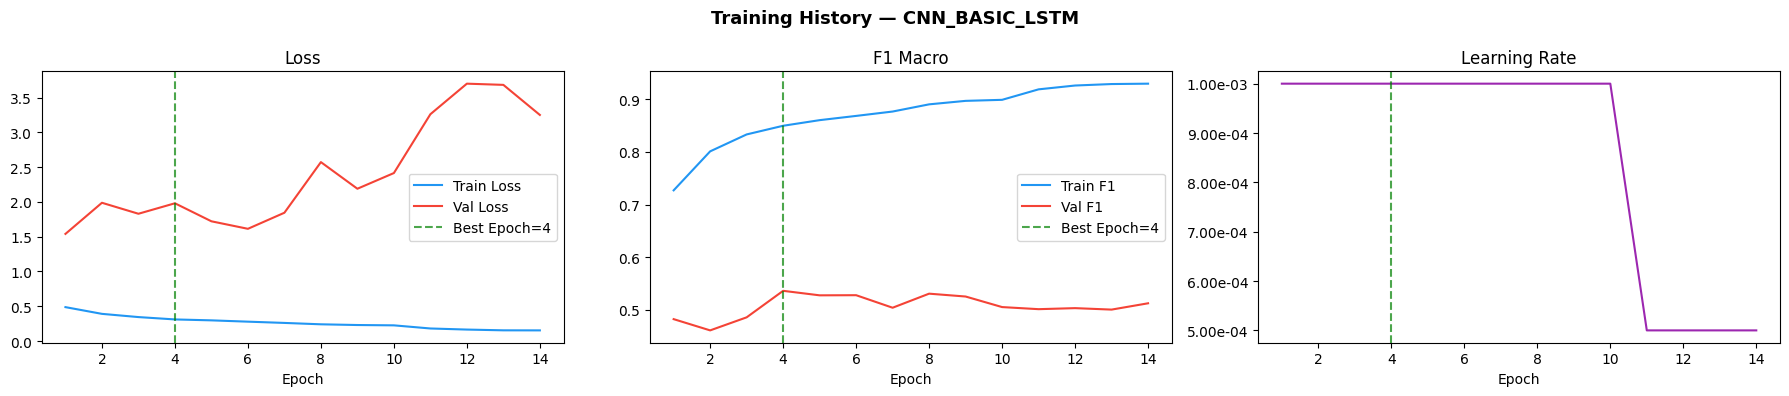

  Tersimpan: C:\kuliah-sementara\SKRIPSI\lstm_models_nthuddd2\CNN_BASIC_LSTM\CNN_BASIC_LSTM_training_curve.png


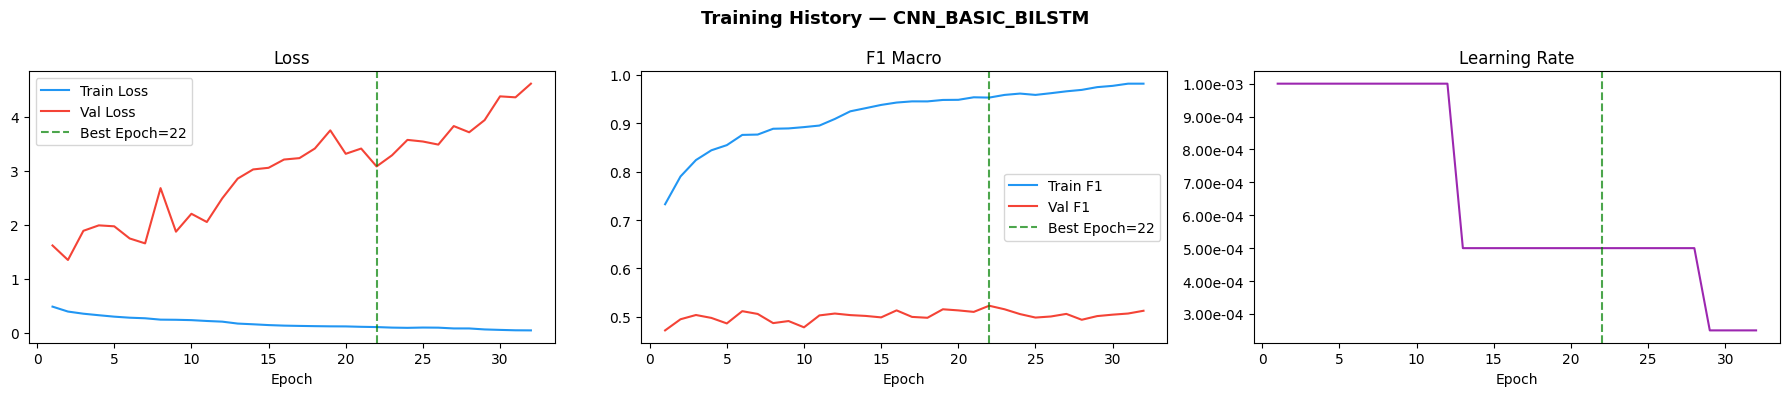

  Tersimpan: C:\kuliah-sementara\SKRIPSI\lstm_models_nthuddd2\CNN_BASIC_BILSTM\CNN_BASIC_BILSTM_training_curve.png


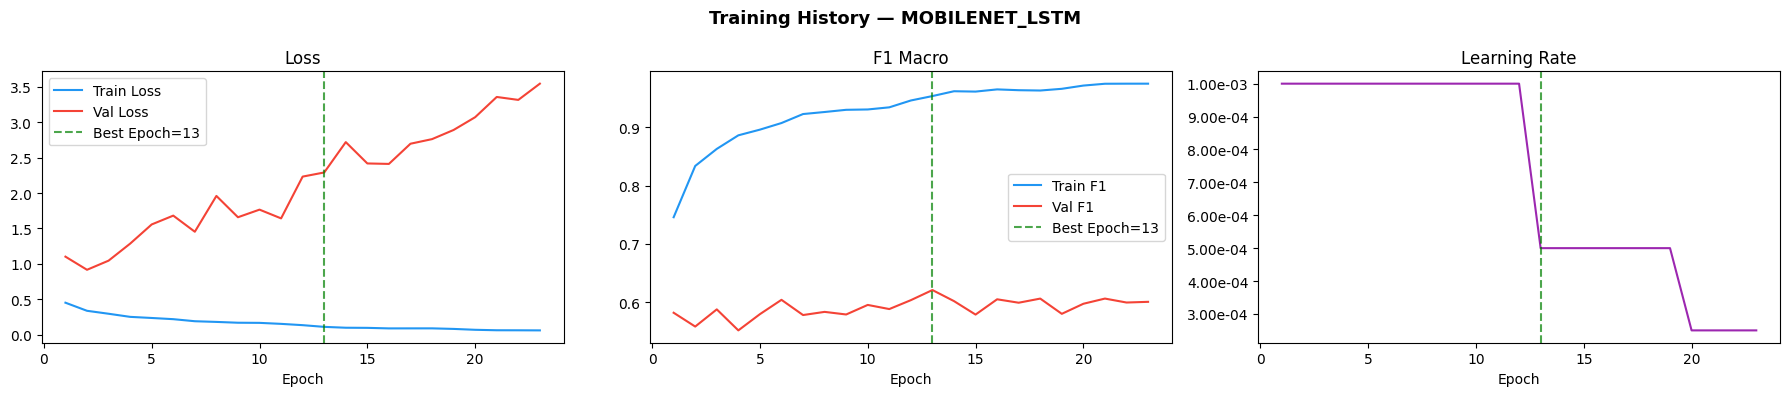

  Tersimpan: C:\kuliah-sementara\SKRIPSI\lstm_models_nthuddd2\MOBILENET_LSTM\MOBILENET_LSTM_training_curve.png


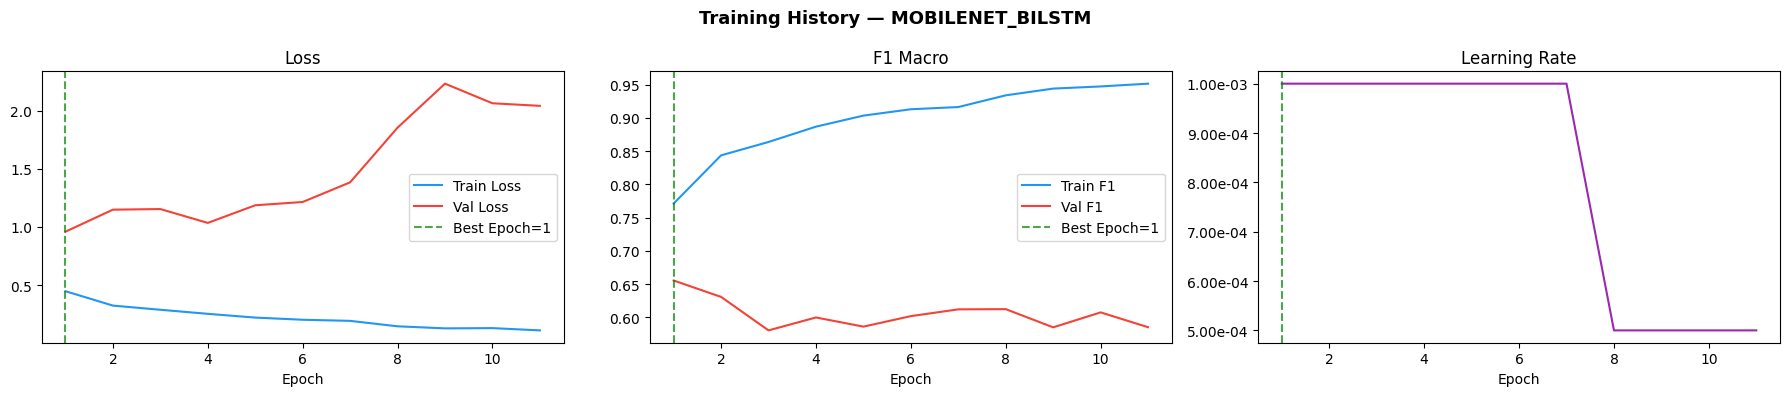

  Tersimpan: C:\kuliah-sementara\SKRIPSI\lstm_models_nthuddd2\MOBILENET_BILSTM\MOBILENET_BILSTM_training_curve.png


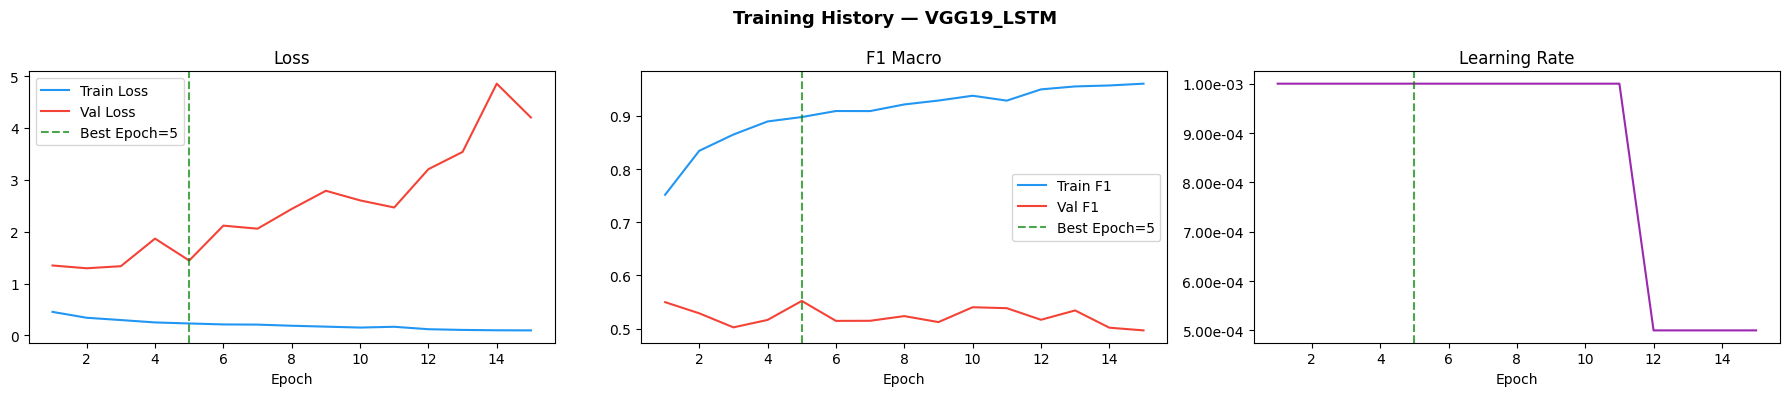

  Tersimpan: C:\kuliah-sementara\SKRIPSI\lstm_models_nthuddd2\VGG19_LSTM\VGG19_LSTM_training_curve.png


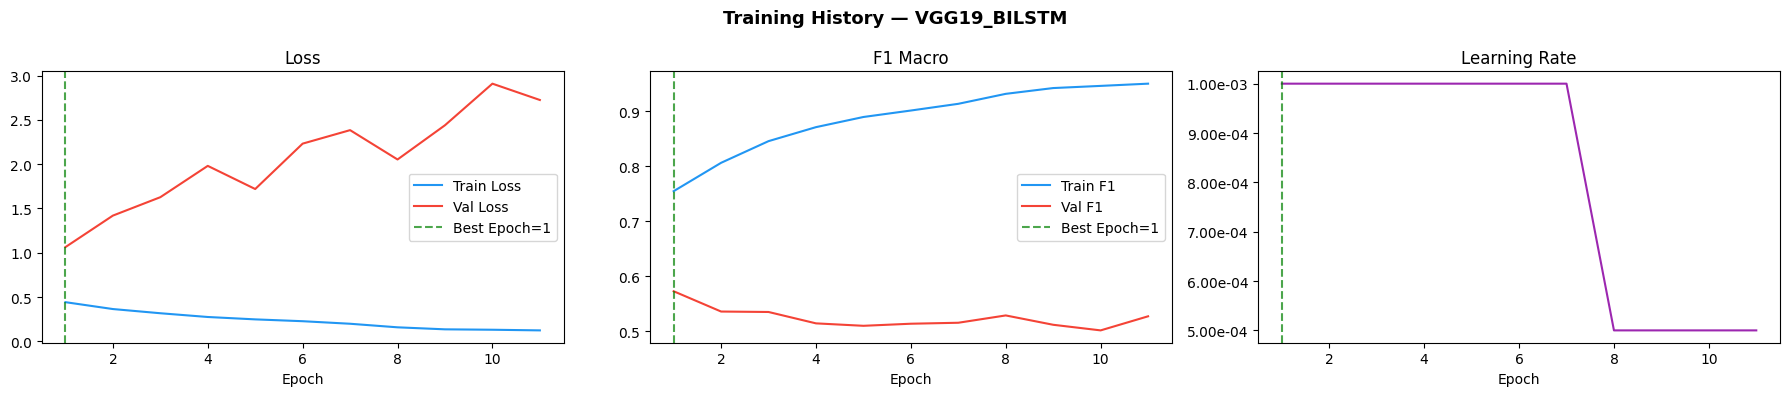

  Tersimpan: C:\kuliah-sementara\SKRIPSI\lstm_models_nthuddd2\VGG19_BILSTM\VGG19_BILSTM_training_curve.png


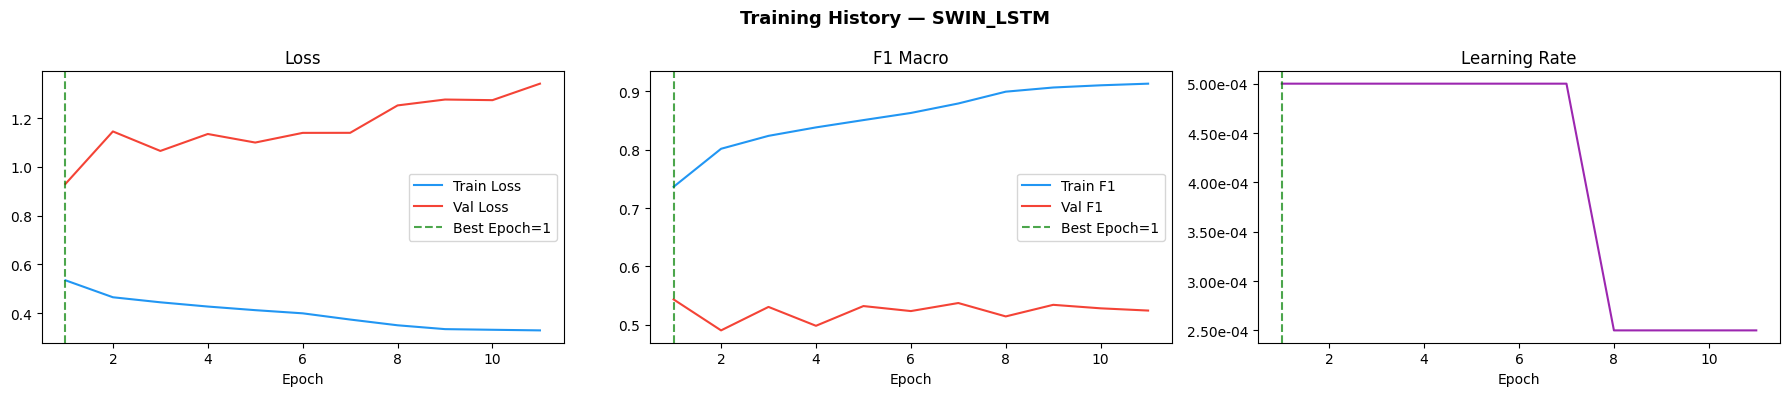

  Tersimpan: C:\kuliah-sementara\SKRIPSI\lstm_models_nthuddd2\SWIN_LSTM\SWIN_LSTM_training_curve.png


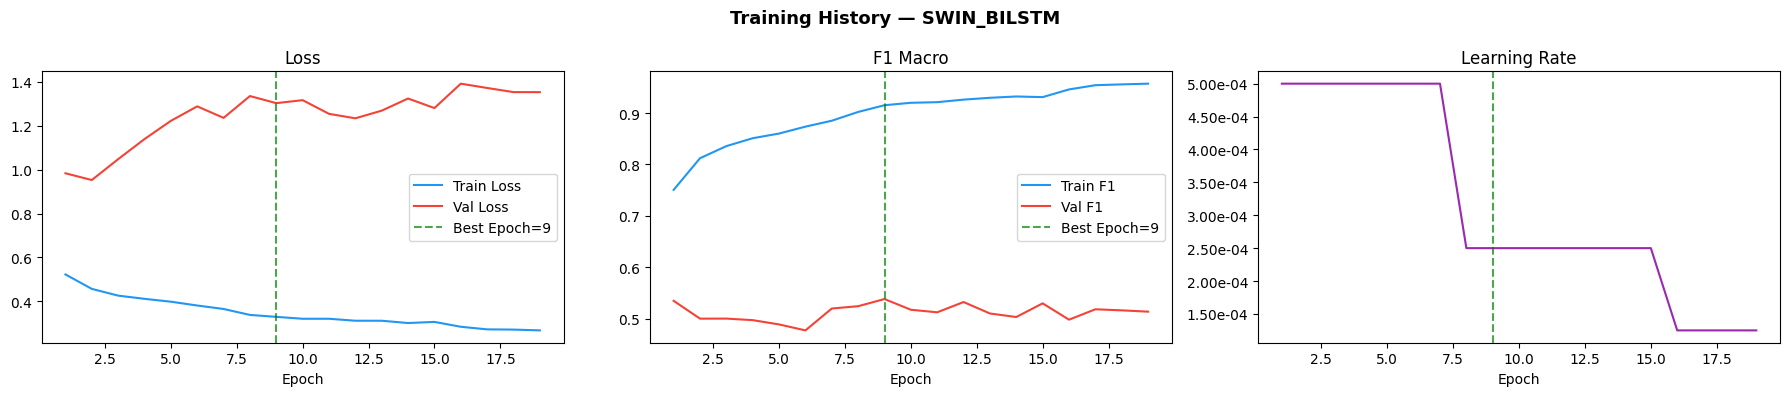

  Tersimpan: C:\kuliah-sementara\SKRIPSI\lstm_models_nthuddd2\SWIN_BILSTM\SWIN_BILSTM_training_curve.png


In [35]:
def plot_training_history(model_id: str):
    """Plot loss, F1 Macro, dan LR dari history JSON."""
    model_dir  = os.path.join(SAVE_DIR, model_id)
    hist_path  = os.path.join(model_dir, f"{model_id}_history.json")

    if not os.path.exists(hist_path):
        print(f"  [SKIP] History tidak ditemukan: {hist_path}")
        return

    with open(hist_path) as f:
        h = json.load(f)

    epochs   = range(1, len(h["train_loss"]) + 1)
    best_ep  = int(np.argmax(h["val_f1"])) + 1

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f"Training History — {model_id}", fontsize=13, fontweight="bold")

    # Loss
    axes[0].plot(epochs, h["train_loss"], label="Train Loss", color="#2196F3")
    axes[0].plot(epochs, h["val_loss"],   label="Val Loss",   color="#F44336")
    axes[0].axvline(best_ep, color="green", linestyle="--", alpha=0.7, label=f"Best Epoch={best_ep}")
    axes[0].set_title("Loss"); axes[0].legend(); axes[0].set_xlabel("Epoch")

    # F1 Macro
    axes[1].plot(epochs, h["train_f1"], label="Train F1", color="#2196F3")
    axes[1].plot(epochs, h["val_f1"],   label="Val F1",   color="#F44336")
    axes[1].axvline(best_ep, color="green", linestyle="--", alpha=0.7, label=f"Best Epoch={best_ep}")
    axes[1].set_title("F1 Macro"); axes[1].legend(); axes[1].set_xlabel("Epoch")

    # Learning Rate
    axes[2].plot(epochs, h["lr"], color="#9C27B0")
    axes[2].axvline(best_ep, color="green", linestyle="--", alpha=0.7)
    axes[2].set_title("Learning Rate"); axes[2].set_xlabel("Epoch")
    axes[2].yaxis.set_major_formatter(mtick.FormatStrFormatter("%.2e"))

    plt.tight_layout()
    save_path = os.path.join(model_dir, f"{model_id}_training_curve.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Tersimpan: {save_path}")


# Semua model
for model_id_key in [f"{bb}_{lt}" for bb in MODELS for lt in ["LSTM", "BILSTM"]]:
    plot_training_history(model_id_key)